In [ ]:
from transformers import AutoModelForImageClassification , AutoImageProcessor, TrainingArguments, Trainer, DefaultDataCollator
from datasets import load_dataset
import numpy as np
import matplotlib.pyplot as plt
from torchvision.transforms import transforms, Compose, ToTensor, Normalize, RandomResizedCrop, RandomHorizontalFlip, Resize
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from torchvision import transforms
import evaluate

In [5]:
model_path = 'google/vit-base-patch16-224-in21k'
process_model = AutoImageProcessor.from_pretrained(model_path)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/502 [00:00<?, ?B/s]

Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.


#### Prepare Dataset

In [25]:
dataset = load_dataset('Folefac/plant-dataset', split='train')

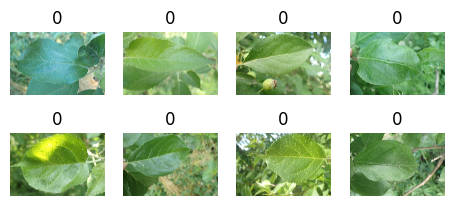

In [16]:
plt.figure(figsize=(4*1.4, 2*1.2))
for i in range(8):
    plt.subplot(2, 4, i+1)
    plt.imshow(dataset[i]['image'])
    plt.title(dataset[i]['label'])
    plt.axis('off')
    

In [7]:
len(dataset)

1532

In [44]:
data_rest = dataset.train_test_split(test_size=0.2)
data_val = data_rest['test'].train_test_split(test_size=0.5)
train_dataset = data_rest['train']
valid_dataset = data_val['train']
test_dataset = data_val['test']
print(len(train_dataset), len(valid_dataset), len(test_dataset))

1225 153 154


In [9]:
normalize = Normalize(mean=process_model.image_mean, std=process_model.image_std)

In [45]:
train_transforms = Compose(
    [RandomHorizontalFlip(0.5),
    RandomResizedCrop(224),
    Resize((224, 224)),
    ToTensor(),
    normalize]
)

valid_transforms = Compose(
   [Resize((224, 224)),
    ToTensor(),
    normalize]
)

test_transforms = Compose(
    [Resize((224, 224)),
    ToTensor(),
    normalize]
)

def apply_transform_train(examples):
    examples['pixel_values'] = [train_transforms(image.convert('RGB')) for image in examples['image']]
    del examples['image']
    return examples

def apply_transform_valid(examples):
    examples['pixel_values'] = [valid_transforms(image.convert('RGB')) for image in examples['image']]
    del examples['image']
    return examples

def apply_transform_test(examples):
    examples['pixel_values'] = [test_transforms(image.convert('RGB')) for image in examples['image']]
    del examples['image']
    return examples

train_dataset = train_dataset.with_transform(apply_transform_train)
valid_dataset = valid_dataset.with_transform(apply_transform_valid)
test_dataset = test_dataset.with_transform(apply_transform_test)
data_collator = DefaultDataCollator()

In [ ]:
train_dataset

#### Model

In [11]:
id2label={
    0 : "Healthy",
    1 : "Powdery",
    2 : 'Rust'
}
label2id={
    "Healthy" : 0,
    "Powdery" : 1,
    'Rust' : 2
}


In [12]:
model = AutoModelForImageClassification.from_pretrained(model_path, num_labels=3, label2id=label2id, id2label=id2label)

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224-in21k
Key                 | Status     | 
--------------------+------------+-
pooler.dense.bias   | UNEXPECTED | 
pooler.dense.weight | UNEXPECTED | 
classifier.weight   | MISSING    | 
classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [13]:
train_args = TrainingArguments(
    output_dir='./plant_output',
    remove_unused_columns=False,
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=5e-5,
    per_device_eval_batch_size=4,
    per_device_train_batch_size=4,
    gradient_accumulation_steps=4,
    num_train_epochs=2,
    warmup_ratio=0.1,
    logging_steps=10, 
    load_best_model_at_end=True,
    push_to_hub=False
)

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


In [32]:
accuracy = evaluate.load('accuracy')

def compute_accuracy(data):
    preds, labels = data
    pred_label = np.argmax(preds, axis=1)
    return accuracy.compute(predictions=pred_label, references=labels)

In [46]:
trainer = Trainer(
    model=model,
    args=train_args,
    data_collator=data_collator,
    train_dataset=train_dataset,
    eval_dataset=valid_dataset,
    compute_metrics=compute_accuracy,
)

In [47]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy
1,0.186236,0.105481,0.986928
2,0.139729,0.087594,0.986928


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=154, training_loss=0.27195949562184224, metrics={'train_runtime': 477.4219, 'train_samples_per_second': 5.132, 'train_steps_per_second': 0.323, 'total_flos': 1.898570761694208e+17, 'train_loss': 0.27195949562184224, 'epoch': 2.0})

In [48]:
outputs = trainer.predict(test_dataset)
outputs.metrics

{'test_loss': 0.05974555388092995,
 'test_accuracy': 1.0,
 'test_runtime': 22.6449,
 'test_samples_per_second': 6.801,
 'test_steps_per_second': 1.722}

In [52]:
y_true = outputs.label_ids
y_pred = outputs.predictions.argmax(1)
labels = test_dataset.features['label'].names


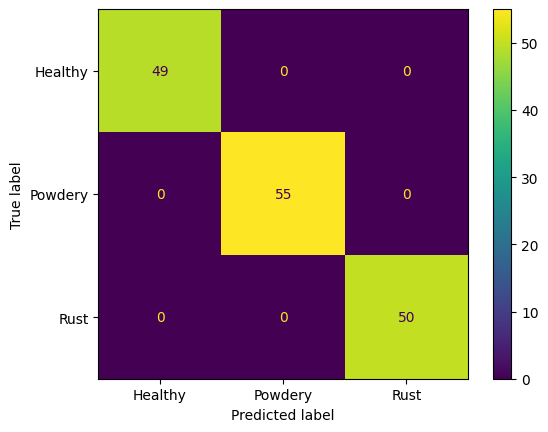

In [56]:
cm = confusion_matrix(y_true, y_pred)
display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
display.plot()

In [58]:
model.push_to_hub('plant-disease')

HfHubHTTPError: Client error '401 Unauthorized' for url 'https://huggingface.co/api/repos/create' (Request ID: Root=1-69e92a85-3912dc863d54608332c963aa;56460ace-e97b-45fb-ad07-dc05776b49bd)
For more information check: https://developer.mozilla.org/en-US/docs/Web/HTTP/Status/401

Invalid username or password.

#### ONNX 

In [ ]:
!pip install onnx onnxruntime

In [ ]:
import torch
dummy_input = torch.randn(1, 3, 224, 224)
input_names = ['pixel_values']
output_names = ['logits']

In [ ]:
## export to ONNXruntime 
torch.onnx.export(
    model,
    dummy_input,
    'vit_clasification.onnx',
    export_params=True,
    opset_version=14,
    do_constant_folding=True,
    input_names=input_names,
    output_names=output_names,
    dynamic_axes={'pixel_values': {0:"batch_size"}, 'logits': {'0':"batch_size"}}
)

In [62]:
## impor from onnx
import onnxruntime as ort

In [ ]:
providers = ['CPUExecutionProvider', 'CUDAExecutionProvider']
session = ort.InferenceSession('vit_clasification.onnx', providers=providers)

In [ ]:
session_input = {session.get_inputs()[0].name: img}
onnx_output = session.run(None, session_input)
onnx_logits = onnx_output[0]
onnx_pred = np.argmax(onnx_logits, axis=1)[0]